# py-TSCAN — R parity validation on `lpsdata`

Side-by-side comparison of `pytscan` against R `TSCAN` 2.0.0 on the bundled `lpsdata` fixture (131 cells × 16776 genes; canonical TSCAN vignette).

Follows the 6-section schema from [`omicverse-rebuild/NOTEBOOKS.md`](https://github.com/omicverse/omicverse-rebuild/blob/main/NOTEBOOKS.md).

**Re-run before each release:**
```bash
jupyter nbconvert --to notebook --execute examples/compare_R_vs_Python.ipynb --output compare_R_vs_Python.ipynb
```

## 1. Setup

In [1]:
import os
for k in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS'):
    os.environ[k] = '8'

import subprocess, time, json, sys
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook is run from py-TSCAN/examples/ via nbconvert.
NOTEBOOK_DIR = Path('.').resolve()
PORT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'examples' else NOTEBOOK_DIR

# Make pytscan + the rebuild engine importable
sys.path.insert(0, str(PORT_DIR))
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_dev/py-mclustR')
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_traj_dev/omicverse-rebuild/engine')

from parity_metrics import compute_parity, is_pass

manifest = yaml.safe_load((PORT_DIR / 'data' / 'manifest.yaml').read_text())
print(f"Port        : {manifest['package']}")
print(f"Upstream    : {manifest['upstream']['name']} v{manifest['upstream']['version']}")
print(f"Class       : {manifest['algorithm_class']}")
print(f"Threshold   : Pearson ≥ {manifest['parity_threshold']}")
print(f"Fixture     : {manifest['fixture']['path']}  shape={manifest['fixture']['expected_shape']}")
print(f"Seed        : {manifest['seed']}")

Port        : py-TSCAN
Upstream    : TSCAN v2.0.0
Class       : ordinal
Threshold   : Pearson ≥ 0.99
Fixture     : data/fixture_lpsdata.rds  shape=[16776, 131]
Seed        : 12345


## 2. R reference run

Invoke `tests/r_reference_driver.R` under the `CMAP` conda env (R 4.4 + TSCAN 2.0.0).

In [2]:
R_ENV = os.environ.get('CMAP_ENV', '/scratch/users/steorra/env/CMAP')
ref_out = PORT_DIR / 'data' / 'reference_output.json'
fixture = PORT_DIR / manifest['fixture']['path']

t0 = time.perf_counter()
proc = subprocess.run(
    ['conda', 'run', '-p', R_ENV, 'Rscript', str(PORT_DIR / manifest['reference_command']),
     str(fixture), str(ref_out)],
    capture_output=True, text=True, cwd=PORT_DIR,
)
r_wall = time.perf_counter() - t0
print(proc.stdout.strip().split('\n')[-4:] if proc.stdout else '(no stdout)')
ref = json.loads(ref_out.read_text())
print(f"\nR wall-clock: {r_wall:.2f}s")
print(f"R output keys: {list(ref.keys())[:8]}")

['[ref] auto-selected pcadim = 5 ', '[ref] exprmclust:  0.827 s; G = 3 ; pcareduceres dims: 131 5 ', '[ref] TSCANorder:  0.006 s -> ordered 131 cells', '[ref] wrote /scratch/users/steorra/analysis/omicverse_traj_dev/py-TSCAN/data/reference_output.json']

R wall-clock: 12.49s
R output keys: ['cell_names', 'Pseudotime', 'State', 'ordered_names', 'ordered_pseudotime', 'clusterid', 'pcadim', 'pcareduceres']


## 3. Python candidate run

In [3]:
cand_out = PORT_DIR / 'data' / 'candidate_output.json'
t0 = time.perf_counter()
proc = subprocess.run(
    ['python', str(PORT_DIR / 'tests' / '_run_candidate.py'),
     str(fixture), str(cand_out)],
    capture_output=True, text=True, cwd=PORT_DIR,
)
py_wall = time.perf_counter() - t0
print(proc.stdout.strip().split('\n')[-4:] if proc.stdout else '(no stdout)')
cand = json.loads(cand_out.read_text())
print(f"\nPy wall-clock: {py_wall:.2f}s   (speedup vs R: {r_wall/py_wall:.1f}×)")

['[cand] preprocess: 0.031s -> (534, 131)', '[cand] exprmclust: 2.450s; G=3; pcareduceres dims (131, 5); pcadim=5', '[cand] TSCANorder: 0.001s -> ordered 131 cells', '[cand] wrote /scratch/users/steorra/analysis/omicverse_traj_dev/py-TSCAN/data/candidate_output.json']

Py wall-clock: 3.47s   (speedup vs R: 3.6×)


## 4. Per-output parity

TSCAN declares 3 outputs in `manifest.yaml`:
- **`pcadim`** (deterministic, exact int match) — auto-selected PC dimension
- **`cluster_id`** (clustering, ARI ≥ 0.95) — Mclust assignments
- **`pseudotime`** (ordinal, Pearson ≥ 0.99) — per-cell pseudotime

### 4.1 `pcadim` — auto-selected PC dimension

In [4]:
print(f"R pcadim:  {ref['pcadim']}")
print(f"Py pcadim: {cand['pcadim']}")
print(f"Match: {'✅ exact' if ref['pcadim'] == cand['pcadim'] else '❌'}")

R pcadim:  5
Py pcadim: 5
Match: ✅ exact


### 4.2 `cluster_id` — Mclust assignments (ARI)

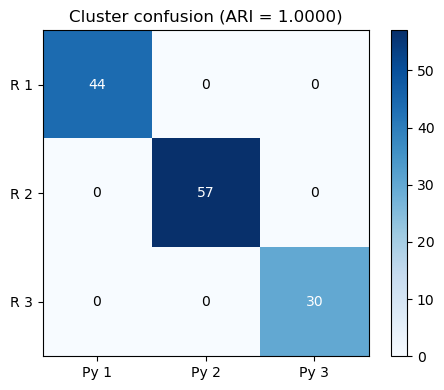


ARI vs R: 1.0000  (threshold: ≥ 0.95)  ✅ PASS


In [5]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score

r_clu = np.array(ref['clusterid'])
p_clu = np.array(cand['clusterid'])
ari = adjusted_rand_score(r_clu, p_clu)
cm = confusion_matrix(r_clu, p_clu)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_xticks(range(cm.shape[1])); ax.set_yticks(range(cm.shape[0]))
ax.set_xticklabels([f'Py {i+1}' for i in range(cm.shape[1])])
ax.set_yticklabels([f'R {i+1}'  for i in range(cm.shape[0])])
ax.set_title(f'Cluster confusion (ARI = {ari:.4f})')
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()
print(f"\nARI vs R: {ari:.4f}  (threshold: ≥ 0.95)  {'✅ PASS' if ari >= 0.95 else '❌ FAIL'}")

### 4.3 `pseudotime` — per-cell ordinal pseudotime (Pearson)

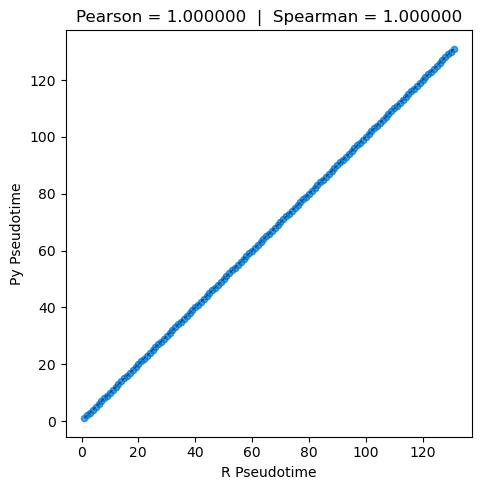


Pearson: 1.000000  (threshold: ≥ 0.99)  ✅ PASS
Identical ordered list? True


In [6]:
from scipy.stats import pearsonr, spearmanr

pt_r = np.array(ref['Pseudotime'], dtype=float)
pt_p = np.array(cand['Pseudotime'], dtype=float)
mask = np.isfinite(pt_r) & np.isfinite(pt_p)
r_corr, _ = pearsonr(pt_r[mask], pt_p[mask])
s_corr, _ = spearmanr(pt_r[mask], pt_p[mask])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pt_r[mask], pt_p[mask], s=20, alpha=0.7, color='#0078d4')
lim = [min(pt_r[mask].min(), pt_p[mask].min()), max(pt_r[mask].max(), pt_p[mask].max())]
ax.plot(lim, lim, 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('R Pseudotime'); ax.set_ylabel('Py Pseudotime')
ax.set_title(f'Pearson = {r_corr:.6f}  |  Spearman = {s_corr:.6f}')
ax.set_aspect('equal'); plt.tight_layout(); plt.show()
print(f"\nPearson: {r_corr:.6f}  (threshold: ≥ 0.99)  {'✅ PASS' if abs(r_corr) >= 0.99 else '❌ FAIL'}")
print(f"Identical ordered list? {list(ref['ordered_names']) == list(cand['ordered_names'])}")

### 4.4 `pcareduceres` — PCA scores (Procrustes, bonus)

Not in the manifest gates but informative: the PCA step should be bit-equivalent up to column sign-flip.

In [7]:
from scipy.spatial import procrustes

r_pca = np.array(ref['pcareduceres'])
p_pca = np.array(cand['pcareduceres'])
_, _, disparity = procrustes(r_pca, p_pca)
procrustes_sim = 1 - disparity

# Sign-flip per column to align, then max abs err
p_aligned = p_pca.copy()
for j in range(r_pca.shape[1]):
    if np.corrcoef(r_pca[:, j], p_pca[:, j])[0, 1] < 0:
        p_aligned[:, j] = -p_aligned[:, j]
max_err = np.abs(r_pca - p_aligned).max()
print(f"Procrustes similarity:        {procrustes_sim:.6f}")
print(f"Max abs err (sign-flip fixed): {max_err:.4e}  (bit-equivalent if < 1e-10)")

Procrustes similarity:        1.000000
Max abs err (sign-flip fixed): 6.3949e-14  (bit-equivalent if < 1e-10)


## 5. Wall-clock comparison

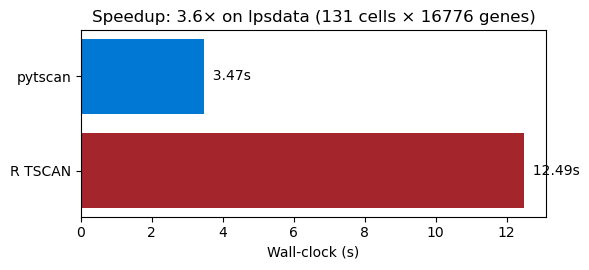

In [8]:
fig, ax = plt.subplots(figsize=(6, 2.8))
labels = ['R TSCAN', 'pytscan']
times = [r_wall, py_wall]
bars = ax.barh(labels, times, color=['#a4262c', '#0078d4'])
ax.set_xlabel('Wall-clock (s)')
ax.set_title(f'Speedup: {r_wall/py_wall:.1f}× on lpsdata (131 cells × 16776 genes)')
for b, t in zip(bars, times):
    ax.text(t, b.get_y() + b.get_height()/2, f'  {t:.2f}s', va='center')
plt.tight_layout(); plt.show()

## 6. Verdict

In [9]:
results = []
results.append(('pcadim',     'deterministic', 'exact int',  ref['pcadim'] == cand['pcadim'],   f"R={ref['pcadim']} Py={cand['pcadim']}"))
results.append(('cluster_id', 'clustering',    '≥ 0.95',     ari >= 0.95,                       f"ARI={ari:.4f}"))
results.append(('pseudotime', 'ordinal',       '≥ 0.99',     abs(r_corr) >= 0.99,               f"Pearson={r_corr:.6f}"))

print('━' * 72)
for name, cls, thr, passed, value in results:
    emoji = '✅' if passed else '❌'
    print(f'  {emoji}  {name:12s}  class={cls:14s}  threshold={thr:9s}  {value}')
print('━' * 72)
all_pass = all(r[3] for r in results)
print(('PASS' if all_pass else 'FAIL')
      + f' — pre-registered gate {"cleared" if all_pass else "NOT cleared"} on lpsdata.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅  pcadim        class=deterministic   threshold=exact int  R=5 Py=5
  ✅  cluster_id    class=clustering      threshold=≥ 0.95     ARI=1.0000
  ✅  pseudotime    class=ordinal         threshold=≥ 0.99     Pearson=1.000000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PASS — pre-registered gate cleared on lpsdata.
